Setting up the libraries

In [1]:
import requests
import pandas as pd
import datetime as dt
import os
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

It is important to set the right working directory for the automatical saving of files

In [2]:
os.getcwd()

'c:\\Users\\vince\\OneDrive\\Počítač\\WU\\3HS\\SBWL_Data_Science\\GK5_Lab'

Setting the output path:

In [3]:
OUTPUT_DIR = Path("forecast_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Setting up the API:

SET API KEY IN TERMINAL BEFORE:

set WEATHERAPI_KEY=...

In [ ]:
import os
API_KEY = os.environ.get("WEATHERAPI_KEY", "your_key_here")

BASE_URL ="http://api.weatherapi.com/v1/forecast.json"
ZONE_LOCATIONS = {
    "DK1": ["Aarhus", "Aalborg", "Esbjerg", "Odense"], 
    "NO2": ["Kristiansand", "Stavanger", "Skien"],     
    "ES":  ["Madrid", "Seville", "Bilbao", "Barcelona"],
    "FR":  ["Nice", "Bordeaux", "Rennes", "Lille"],
    "DE_LU" : ["Stuttgart", "Munich", "Berlin", "Düsseldorf"]
}

Using a slitly modified version of the last semesters group function to fetch the data only for day-ahead weather.

In [5]:
def fetch_city_forecast(city, days=2):
    """
    Fetches forecast for a specific city.
    Returns a DataFrame with only tomorrow's forecast.
    """
    params = {
        'key': API_KEY,
        'q': city,
        'days': days,  # Fetch 2 days (today + tomorrow)
        'aqi': 'no',
        'alerts': 'no'
    }
    
    try:
        response = requests.get(BASE_URL, params=params)
        data = response.json()
        
        if 'error' in data:
            print(f"[ERROR] Fetching {city}: {data['error']['message']}")
            return pd.DataFrame()
        
        # Get tomorrow's date
        tomorrow = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
        
        forecast_days = data['forecast']['forecastday']
        hourly_list = []
        
        for day in forecast_days:
            # Filter for tomorrow only
            if day['date'] != tomorrow:
                continue
            
            for hour in day['hour']:
                solar_rad = hour.get('short_rad')
                if solar_rad is None:
                    uv_index = hour.get('uv', 0.0)
                    solar_rad = uv_index * 25.0
                
                hourly_list.append({
                    'time_local': hour['time'],
                    'temperature_2m': hour.get('temp_c'),
                    'precipitation_mm': hour.get('precip_mm'),
                    'wind_kph': hour.get('wind_kph'),
                    'solar_radiation_W': solar_rad
                })
        
        df = pd.DataFrame(hourly_list)
        df['time'] = pd.to_datetime(df['time_local'])
        return df
        
    except Exception as e:
        print(f"[EXCEPTION] Fetching {city}: {e}")
        return pd.DataFrame()

Now calculating the zonal mean and saving the files

In [6]:
def process_and_save_forecasts():
    print("Starting Forecast Ingestion...")
    print("-" * 30)
    
    for zone, cities in ZONE_LOCATIONS.items():
        print(f"Processing Zone: {zone}")
        all_cities_dfs = []
        
        # 1. Fetch data for each city
        for city in cities:
            df_city = fetch_city_forecast(city)
            if not df_city.empty:
                df_city = df_city.set_index('time')
                all_cities_dfs.append(df_city)
        
        if not all_cities_dfs:
            print(f"[SKIP] {zone}: No data fetched.")
            continue
            
        # 2. Aggregate (Spatial Mean)
        # Concatenate all city dataframes
        df_combined = pd.concat(all_cities_dfs)
        
        # Calculate mean, ignoring non-numeric columns (like 'time_local')
        df_zonal_mean = df_combined.groupby(df_combined.index).mean(numeric_only=True)
        
        # 3. Feature Engineering
        # Convert Wind Speed: kph -> m/s (1 m/s = 3.6 kph)
        if 'wind_kph' in df_zonal_mean.columns:
            df_zonal_mean['wind_speed_10m'] = df_zonal_mean['wind_kph'] / 3.6
        
        # Select and Reorder Final Columns
        final_cols = [
            'temperature_2m', 
            'precipitation_mm', 
            'wind_speed_10m', 
            'solar_radiation_W'
        ]
        
        # Ensure columns exist (fill 0.0 if missing)
        for col in final_cols:
            if col not in df_zonal_mean.columns:
                df_zonal_mean[col] = 0.0
                
        df_final = df_zonal_mean[final_cols]
        
        # 4. Save to CSV
        save_path = OUTPUT_DIR / f"{zone}_forecast.csv"
        df_final.to_csv(save_path)
        
        print(f"[SUCCESS] Saved: {save_path.name}")
        print(f"Time Range: {df_final.index.min()} to {df_final.index.max()}")
        print("-" * 30)

# Run the pipeline
if __name__ == "__main__":
    process_and_save_forecasts()

Starting Forecast Ingestion...
------------------------------
Processing Zone: DK1
[SUCCESS] Saved: DK1_forecast.csv
Time Range: 2026-05-20 00:00:00 to 2026-05-20 23:00:00
------------------------------
Processing Zone: NO2
[SUCCESS] Saved: NO2_forecast.csv
Time Range: 2026-05-20 00:00:00 to 2026-05-20 23:00:00
------------------------------
Processing Zone: ES
[SUCCESS] Saved: ES_forecast.csv
Time Range: 2026-05-20 00:00:00 to 2026-05-20 23:00:00
------------------------------
Processing Zone: FR
[SUCCESS] Saved: FR_forecast.csv
Time Range: 2026-05-20 00:00:00 to 2026-05-20 23:00:00
------------------------------
Processing Zone: DE_LU
[SUCCESS] Saved: DE_LU_forecast.csv
Time Range: 2026-05-20 00:00:00 to 2026-05-20 23:00:00
------------------------------


Sanity Check:

In [7]:
def check_data_quality():
    print("\n--- Running Sanity Checks ---")
    
    for zone in ZONE_LOCATIONS.keys():
        file_path = OUTPUT_DIR / f"{zone}_forecast.csv"
        
        if not file_path.exists():
            continue
            
        print(f"\nZone: {zone}")
        df = pd.read_csv(file_path, index_col=0, parse_dates=True)
        
        # 1. Missing Values
        missing = df.isna().sum().sum()
        if missing > 0:
            print(f"[WARNING] Found {missing} missing values.")
        else:
            print("[OK] No missing values.")
            
        # 2. Physical Constraints
        if df['wind_speed_10m'].min() < 0:
            print("[CRITICAL] Negative wind speed detected.")
        
        if df['solar_radiation_W'].min() < 0:
            print("[CRITICAL] Negative solar radiation detected.")
            
        # 3. Print Stats
        print(df.describe().loc[['min', 'max', 'mean']])

check_data_quality()


--- Running Sanity Checks ---

Zone: DK1
[OK] No missing values.
      temperature_2m  precipitation_mm  wind_speed_10m  solar_radiation_W
min         9.750000          0.000000        3.722222           0.000000
max        13.975000          0.800000        6.576389         422.485000
mean       11.914583          0.192604        4.916956         141.179062

Zone: NO2
[OK] No missing values.
      temperature_2m  precipitation_mm  wind_speed_10m  solar_radiation_W
min         8.333333          0.003333        2.703704           0.000000
max        10.800000          0.926667        6.361111          78.260000
mean       10.025000          0.291389        3.858025          30.766667

Zone: ES
[OK] No missing values.
      temperature_2m  precipitation_mm  wind_speed_10m  solar_radiation_W
min        15.225000               0.0        1.173611           0.000000
max        24.650000               0.0        3.701389         952.225000
mean       19.985417               0.0        2.416

Visualization if needed:

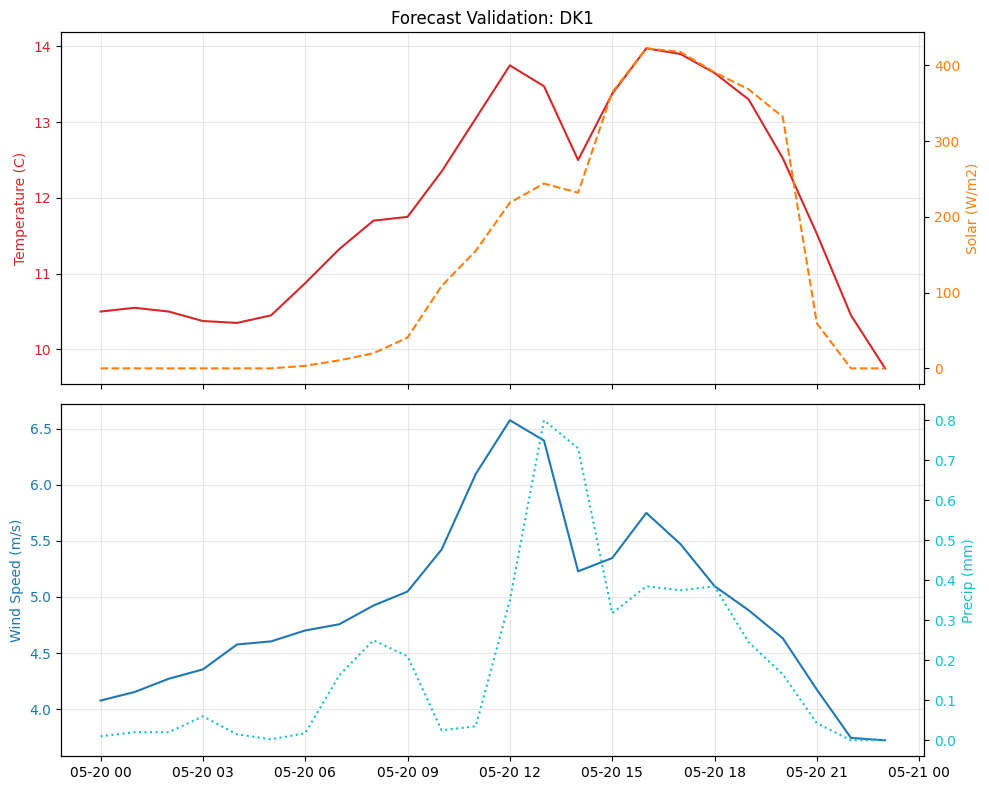

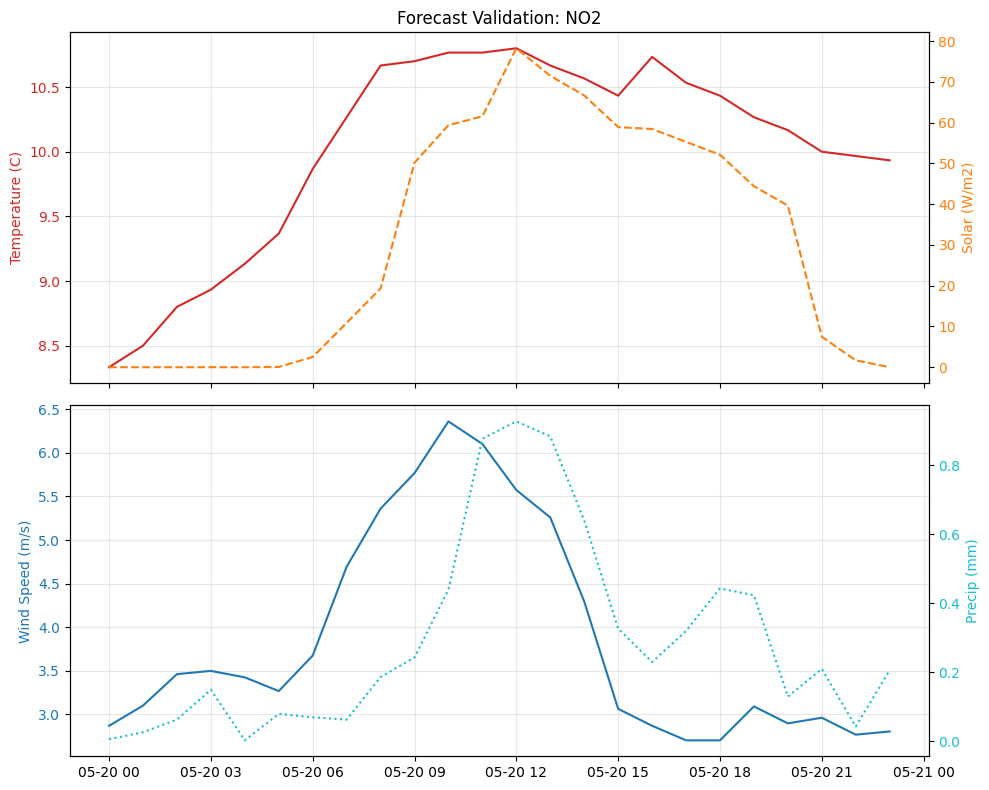

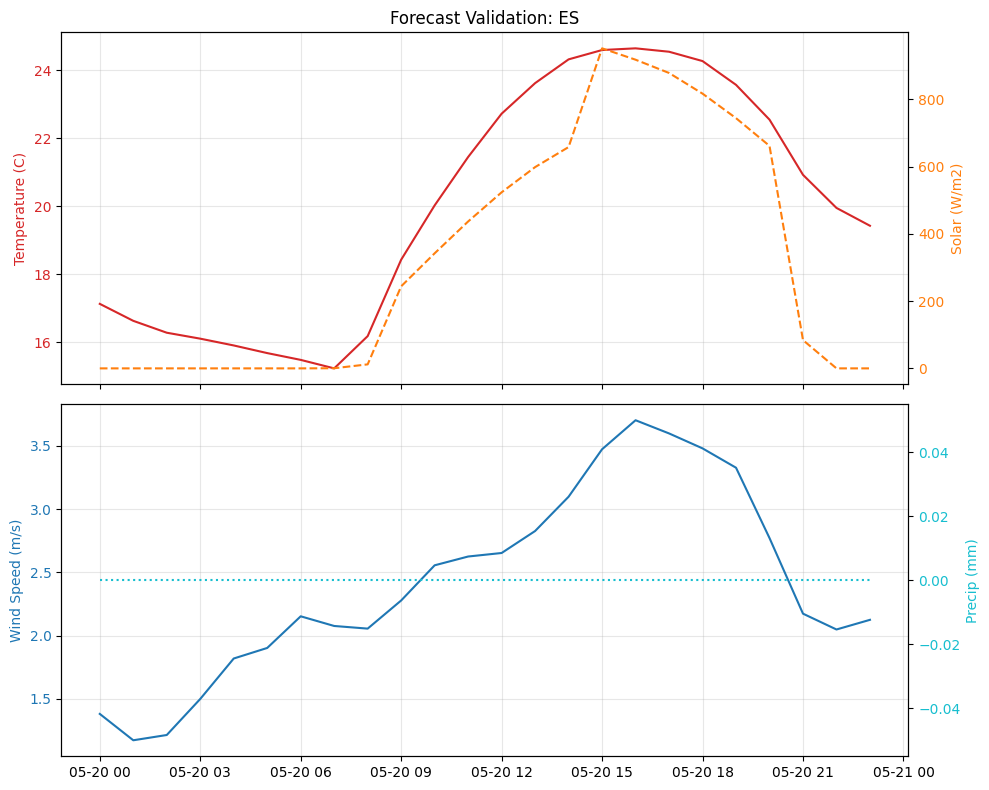

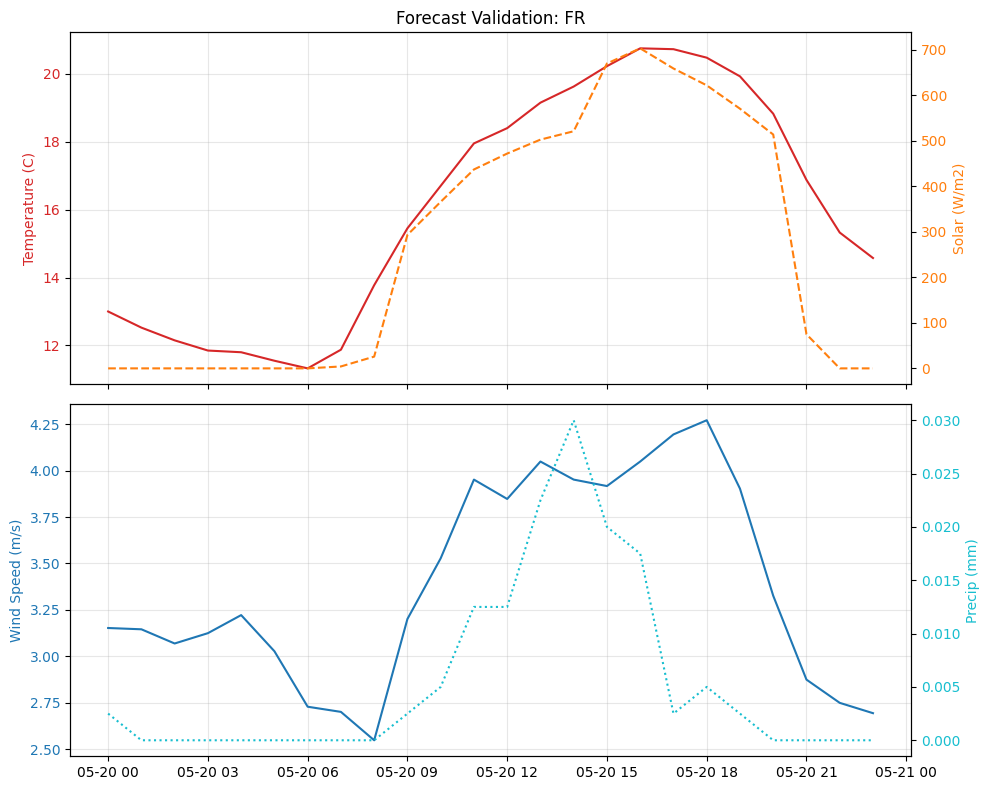

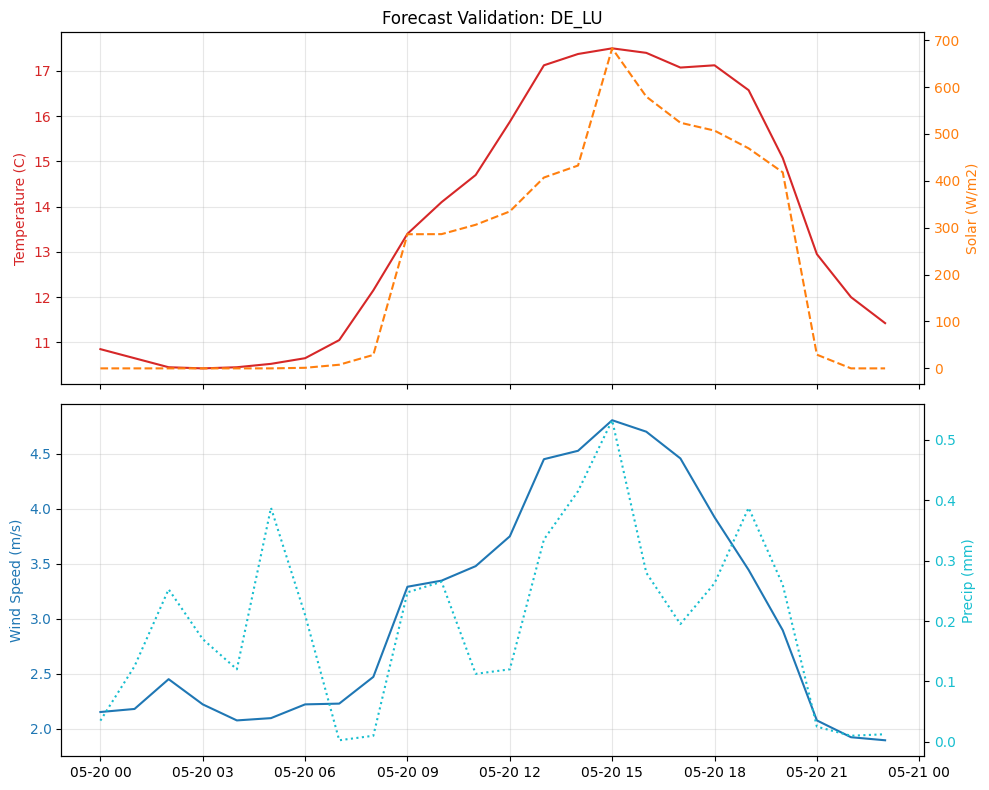

In [8]:
def plot_forecasts():
    for zone in ZONE_LOCATIONS.keys():
        file_path = OUTPUT_DIR / f"{zone}_forecast.csv"
        if not file_path.exists():
            continue
            
        df = pd.read_csv(file_path, index_col=0, parse_dates=True)
        
        # Setup Plot (2 Rows: Temp/Solar and Wind/Precip)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
        
        # Row 1: Temperature & Solar
        color_temp = 'tab:red'
        ax1.set_ylabel('Temperature (C)', color=color_temp)
        ax1.plot(df.index, df['temperature_2m'], color=color_temp, label='Temp')
        ax1.tick_params(axis='y', labelcolor=color_temp)
        ax1.grid(True, alpha=0.3)
        
        ax1_right = ax1.twinx()
        color_solar = 'tab:orange'
        ax1_right.set_ylabel('Solar (W/m2)', color=color_solar)
        ax1_right.plot(df.index, df['solar_radiation_W'], color=color_solar, label='Solar', linestyle='--')
        ax1_right.tick_params(axis='y', labelcolor=color_solar)
        ax1.set_title(f"Forecast Validation: {zone}")
        
        # Row 2: Wind & Precip
        color_wind = 'tab:blue'
        ax2.set_ylabel('Wind Speed (m/s)', color=color_wind)
        ax2.plot(df.index, df['wind_speed_10m'], color=color_wind, label='Wind')
        ax2.tick_params(axis='y', labelcolor=color_wind)
        ax2.grid(True, alpha=0.3)
        
        ax2_right = ax2.twinx()
        color_rain = 'tab:cyan'
        ax2_right.set_ylabel('Precip (mm)', color=color_rain)
        ax2_right.plot(df.index, df['precipitation_mm'], color=color_rain, label='Rain', linestyle=':')
        ax2_right.tick_params(axis='y', labelcolor=color_rain)
        
        plt.tight_layout()
        plt.show()

plot_forecasts()